# Kepler's Laws Applied to Mars Orbit Analysis

This notebook investigates Mars' orbit by verifying and illustrating **Kepler's Laws** using computed ephemeris data. Building on previously triangulated Mars positions (from `computed_Mars_orbit.csv`), the analysis is organized into three key sections. This work is part of a broader series demonstrating how **observational data** can be leveraged to study celestial mechanics.

**Contact:** Luca.Canali@cern.ch  
**Date:** February 2025

---

## 1. Kepler's 1st Law: Elliptical Orbits

- **Objective:**  
  - Verify that the computed Mars orbit adheres to Kepler's First Law by confirming that it is an ellipse
  - Verify that the fitted parameters match accepted values, notable eccentricity e ~ 0.09 and semi-major axis a ~ 1.5 AU.

- **Method:**  
  - Convert the triangulated Cartesian coordinates (Mars_X, Mars_Y) into polar coordinates.
  - Use non-linear least squares (via SciPy's `curve_fit`) to fit the polar form of an ellipse:
    $r(\theta) = a \, \frac{1-e^2}{1 + e \cos(\theta-\phi)}$
  - Extract the ellipse parameters:
    - **Semi-major axis (a):** Represents the average distance from Mars to the Sun.
    - **Eccentricity (e):** Indicates how much the orbit deviates from a perfect circle.
    - **Argument of Periapsis (φ):** Specifies the orientation of the ellipse, i.e., the direction of Mars' closest approach to the Sun.

- **Visualization:**  
  Plot the fitted ellipse alongside the measured Mars orbit, with the Sun at the origin and Earth's orbit depicted as a unit circle.

---

## 2. Kepler's 2nd Law: Equal Areas in Equal Times

- **Objective:**  
  Validate that Mars sweeps out equal areas in equal time intervals, in accordance with Kepler's Second Law.

- **Method:**  
  - Compute the area swept by Mars between consecutive positions using the triangle area formula.
  - Analyze the areal velocity by calculating the mean and standard deviation of these daily swept areas.

- **Visualization:**  
  Create a scatter plot of the daily swept areas, with the average value and a ±1 standard deviation band overlaid for reference.

---

## 3. Kepler's 3rd Law: The Harmonic Law

- **Objective:**  
  Demonstrate that the ratio $\frac{T^2}{a^3}$ remains constant for Mars and Earth, as predicted by Kepler's 3rd Law.

- **Method:**  
  - Calculate the ratio $\frac{T^2}{a^3}$ for Mars using its measured orbital period and the fitted semi-major axis.
  - Compare this value with that for Earth and verify that the computed ratios are nearly identical, confirming that the orbital period squared divided by the cube of the semi-major axis is a constant, a reflection of the harmonic nature of planetary motion.
---


In [1]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Read CSV data and
# -------------------------------
folder = "../Data/"
csv_filename = "computed_Mars_orbit.csv"
df = pd.read_csv(folder+csv_filename)

df

,Day N#,Start_Date,Mars_X,Mars_Y,Measurements_used
0,0,2000-01-01,1.387911,-0.007656,11
1,1,2000-01-02,1.390132,0.006632,10
2,2,2000-01-03,1.391546,0.020397,11
3,3,2000-01-04,1.391945,0.035610,11
4,4,2000-01-05,1.392190,0.050820,11
...,...,...,...,...,...
683,683,2001-11-14,1.383289,-0.068702,10
684,684,2001-11-15,1.384593,-0.053520,10
685,685,2001-11-16,1.385745,-0.038333,10
686,686,2001-11-17,1.386745,-0.023141,10


## Kepler's 1st Law

In [2]:
# -------------------------------
# Fit an Elipse to the estimated Mars orbit
# -------------------------------

import numpy as np
from scipy.optimize import curve_fit

# Extract the estimated Mars positions (in astronomical units) from the DataFrame.
# Assumes df_results has been defined previously with columns "Mars_X" and "Mars_Y".
mars_x = df["Mars_X"].values  # Mars x-coordinates (AU)
mars_y = df["Mars_Y"].values  # Mars y-coordinates (AU)

# Convert Cartesian coordinates (x, y) to polar coordinates (r, theta)
# - theta: angle from the positive x-axis (in radians)
# - r: radial distance from the origin (Sun)
theta_data = np.arctan2(mars_y, mars_x)
r_data = np.sqrt(mars_x**2 + mars_y**2)

# Define the polar equation of an ellipse with one focus at the origin (the Sun):
#   r(θ) = a * (1 - e²) / (1 + e * cos(θ - φ))
# where:
#   a   : semi-major axis,
#   e   : eccentricity,
#   φ   : orientation angle (in radians) of the ellipse.
def ellipse_r(theta, a, e, phi):
    """Compute the radial distance for a given angle theta based on ellipse parameters."""
    return a * (1 - e**2) / (1 + e * np.cos(theta - phi))

# Set an initial guess for the ellipse parameters:
# - a ~ 1.5 AU (semi-major axis)
# - e ~ 0.1 (eccentricity)
# - φ ~ 0 radians (orientation)
initial_guess = [1.5, 0.1, 0.0]

# Fit the ellipse model to the Mars polar data using non-linear least squares.
# curve_fit returns the optimized parameters and the covariance matrix.
params, _ = curve_fit(ellipse_r, theta_data, r_data, p0=initial_guess)

# Unpack the fitted ellipse parameters.
a_fit, e_fit, phi_fit = params

print("Fitted Mars Orbit Ellipse Parameters:")
print(f"  Semi-major axis (a): {a_fit:.3f} AU")
print("    -> Represents the average distance from Mars to the Sun.")
print(f"  Eccentricity (e): {e_fit:.3f}")
print("    -> Measures the orbit's deviation from a perfect circle (0 = circular, 0 < e < 1 = elliptical).")
print(f"  Argument of Periapsis (φ): {phi_fit:.3f} radians")
print("    -> Indicates the orientation of the ellipse (the direction of Mars' closest approach to the Sun).")


Fitted Mars Orbit Ellipse Parameters:
  Semi-major axis (a): 1.523 AU
    -> Represents the average distance from Mars to the Sun.
  Eccentricity (e): 0.097
    -> Measures the orbit's deviation from a perfect circle (0 = circular, 0 < e < 1 = elliptical).
  Argument of Periapsis (φ): -0.462 radians
    -> Indicates the orientation of the ellipse (the direction of Mars' closest approach to the Sun).


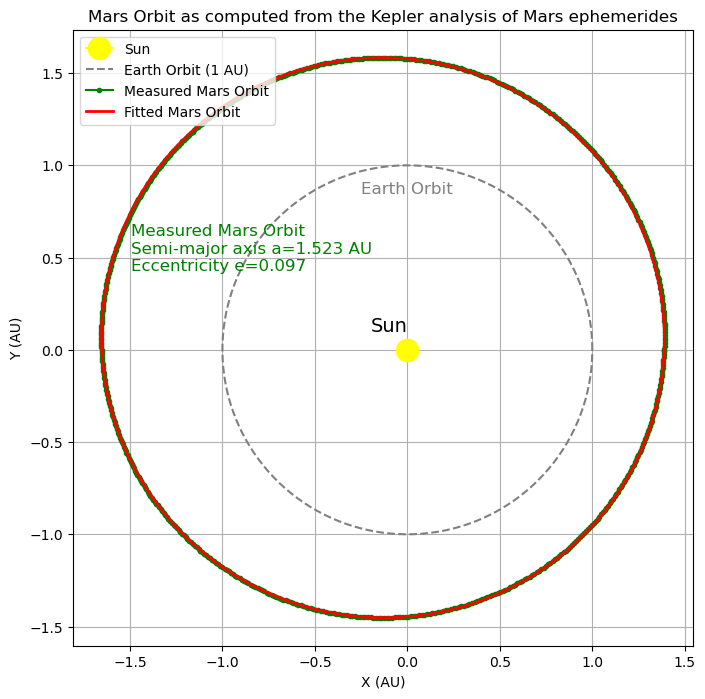

In [3]:
# -------------------------------
# Visualization: Plot Sun, Earth's Orbit, Mars Orbit (in green),
# and the Fitted Mars Orbit (ellipse)
# -------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Plot the Sun at the origin
plt.plot(0, 0, marker='o', color='yellow', markersize=16, label='Sun')
plt.text(-0.2, 0.1, 'Sun', fontsize=14, color='black')

# Plot Earth's orbit (unit circle)
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), '--', color='grey', label='Earth Orbit (1 AU)')
# Manually position the Earth orbit label
plt.text(-0.25, 0.85, 'Earth Orbit', fontsize=12, color='grey')

# Plot the estimated Mars orbit in green (from triangulation)
plt.plot(df["Mars_X"], df["Mars_Y"], 'g.-', 
         label="Measured Mars Orbit", markersize=6)
if not df.empty:
    mid_idx = len(df) // 2
    plt.text(df["Mars_X"].iloc[mid_idx] + 0.15,
             df["Mars_Y"].iloc[mid_idx] + 0.2,
             f"Measured Mars Orbit\nSemi-major axis a={a_fit:.3f} AU\nEccentricity e={e_fit:.3f}",
             fontsize=12, color='green')

# --- Fitted Ellipse ---
# Assumes the ellipse model function ellipse_r(theta, a, e, phi) is defined
# and that the fitted parameters a_fit, e_fit, and phi_fit are available.
# Generate theta values for plotting the fitted ellipse.
theta_fit = np.linspace(0, 2*np.pi, 300)
# Compute the radial distance from the ellipse equation.
r_fit = ellipse_r(theta_fit, a_fit, e_fit, phi_fit)
# Convert the polar coordinates (r_fit, theta_fit) back to Cartesian (x, y).
x_fit = r_fit * np.cos(theta_fit)
y_fit = r_fit * np.sin(theta_fit)
# Plot the fitted ellipse in blue.
plt.plot(x_fit, y_fit, '-', linewidth=2, color='red', label="Fitted Mars Orbit")

plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Mars Orbit as computed from the Kepler analysis of Mars ephemerides")
plt.legend(loc="upper left")
plt.axis("equal")
plt.grid(True)
plt.show()


## Kepler's 2nd Law

Kepler's 2nd Law, also known as the Law of Equal Areas, states that a line joining a planet and the Sun sweeps out equal areas during equal intervals of time. This implies that the planet travels faster when it is closer to the Sun and slower when it is farther away.

In the cell below, we calculate the area swept by Mars over consecutive days using its estimated positions. By demonstrating that these areas are nearly constant (within a small mean and standard deviation), we verify that Mars' orbit adheres to Kepler's 2nd Law.


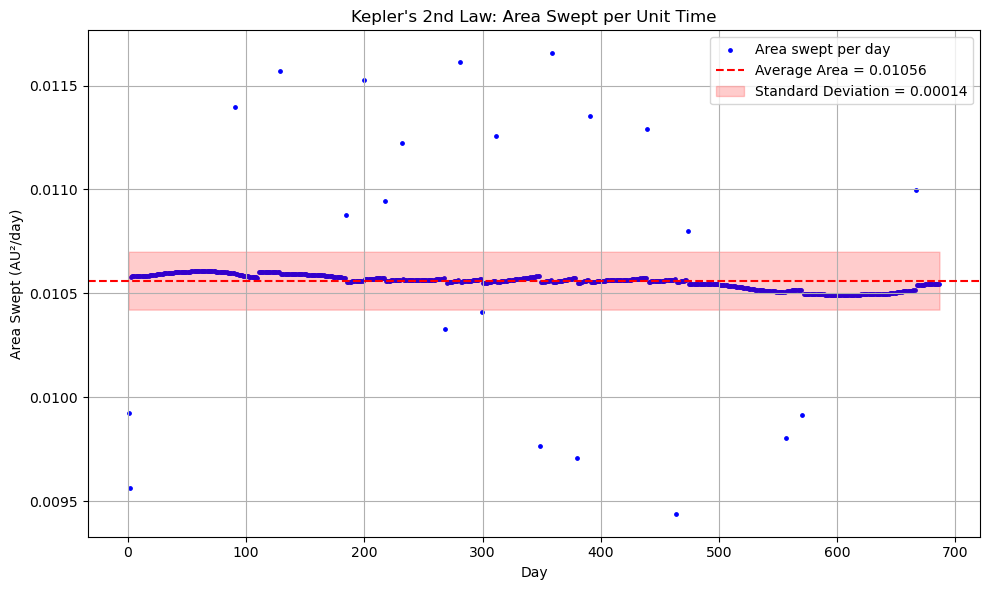

Area swept per unit time is 0.01056 ± 0.00014 AU²/day


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with columns: 'Day', 'Mars_X', 'Mars_Y'
# For example:
# df = pd.read_csv('mars_data.csv')

# Extract position arrays
x = df['Mars_X'].values
y = df['Mars_Y'].values

# Compute the swept area between consecutive days using the triangle area formula
# area_i = 0.5 * |x_i * y_(i+1) - y_i * x_(i+1)|
swept_area = 0.5 * np.abs(x[:-1] * y[1:] - y[:-1] * x[1:])

# Compute the mid-time for each interval (since the time step is 1 day)
mid_days = (df['Day N#'].values[:-1] + df['Day N#'].values[1:]) / 2

# Calculate average area and standard deviation (error)
area_mean = np.mean(swept_area)
area_std = np.std(swept_area)

# Plotting the swept area per day using a scatter plot (no lines connecting the dots)
plt.figure(figsize=(10, 6))
plt.scatter(mid_days, swept_area, color='blue', s=6, label='Area swept per day')

# Plot the average areal velocity as a horizontal dashed line
plt.axhline(area_mean, color='red', linestyle='--', label=f'Average Area = {area_mean:.5f}')

# Shade the area corresponding to ±1 standard deviation (error band)
plt.fill_between(mid_days, area_mean - area_std, area_mean + area_std, color='red', alpha=0.2,
                 label=f'Standard Deviation = {area_std:.5f}')

plt.xlabel('Day')
plt.ylabel('Area Swept (AU²/day)')
plt.title("Kepler's 2nd Law: Area Swept per Unit Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the recap message
print(f"Area swept per unit time is {area_mean:.5f} ± {area_std:.5f} AU²/day")

## Kepler's 3rd Law

For any planet, the orbital period squared is proportional to the cube of the semi-major axis:

$$
T^2 \propto a^3 \quad \Rightarrow \quad \frac{T^2}{a^3} = \text{constant}
$$

**Earth:**  
- T = 365.25 days  
- a = 1 AU  

$$
\frac{T^2}{a^3} \approx 365.25^2 \approx 133407.56 \, (\text{days})^2
$$

**Mars:**  
- T = 687 days  
- a measured ~ 1.523 AU

$$
\frac{T^2}{a^3} \approx \frac{687^2}{1.523^3} \approx 133407.80 \, (\text{days})^2
$$

The nearly identical ratios (error < 0.001%) confirm that the system follows Kepler's Third Law (data for more planets is required to further experimentally prove this)
